# Nomophobia (3-Class) — Federated Learning + DP + Secure Aggregation (ULCER Pipeline Style)

This notebook **combines** the *ULCER+FL* pipeline structure (DP-SGD + secure aggregation + encryption + pro plots + results saving) with the **Nomophobia hyperparameters** (rounds, epochs, LR, batch size, weight decay, clients) and a **3-class** target:

- **Normal (0)**
- **Mild (1)**
- **Severe (2)**

> Notes  
> - Feature selection is **removed** (as requested).  
> - Edit **only Cell 2** to change paths, model type, and hyperparameters.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# Cell 1 — Install + Imports
# =========================
!pip -q install scikit-learn tqdm openpyxl

import os
import math
import time
import random
import copy
import numpy as np
import pandas as pd

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, f1_score,
    confusion_matrix, matthews_corrcoef,recall_score, balanced_accuracy_score,
    roc_auc_score, roc_curve, auc
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

print("Torch:", torch.__version__)


Torch: 2.9.0+cpu


In [ ]:
# ===========================================
# Cell 2 — ALL PARAMETERS (edit only this cell)
# ===========================================
CFG = {
    # ---------- DATA ----------
    # If TEST_CSV_PATH does not exist, the code will split TRAIN_CSV_PATH into train/test using TEST_SIZE.
    "TRAIN_CSV_PATH": "/content/drive/MyDrive/Dataset/Nomophobia/Nomophobia_Train.csv",
    "TEST_CSV_PATH":  "/content/drive/MyDrive/Dataset/Nomophobia/Nomophobia_Test.csv",  # optional
    "LABEL_COL": None,              # None = last column
    "TEST_SIZE": 0.20,
    "RANDOM_SEED": 42,
    "TEST_HAS_LABELS": True,     # True = can compute CM/metrics on unseen test
    "EXPORT_UNSEEN_PRED": True,  # also export predictions/probabilities for the unseen test

    "DROP_COLS": ["User_ID", "NOMO_Class", "NOMO_RiskScore"],  # prevent ID/target leakage
    "AUTO_DROP_LEAKY_COLS": True,

    "ENCODING_MODE": "onehot",   # "onehot" (best), or "label" (compact, usually worse)



    # Class names (fixed order for figures)
    "CLASS_NAMES": ["Normal", "Mild", "Severe"],   # 0,1,2

    # ---------- CLIENT SPLIT (FL) ----------
    # (Nomophobia hyperparameters)
    "NUM_CLIENTS": 5,
    "NONIID": True,                 # True = Dirichlet (non-IID), False = IID split
    "DIRICHLET_ALPHA": 0.5,         # smaller => more non-IID (0.1–0.5 strong, 1.0 mild)

    # ---------- MODEL ----------
    # Choose one: "cnn", "rnn", "lstm", "bilstm", "gnn", "mlp" (ANN/MLP)
    "MODEL_TYPE": "rnn",

    # Declare all model names (requested)
    "MODEL_NAMES": ["CNN", "RNN", "LSTM", "Bi-LSTM", "GNN", "ANN", "MLP"],

    # Model configs (Nomophobia defaults)
    "DL_MODEL_CONFIG": {
        "cnn":   {"channels1": 32, "channels2": 64, "dropout": 0.30},
        "rnn":   {"hidden_dim": 64, "num_layers": 1, "dropout": 0.30},
        "lstm":  {"hidden_dim": 64, "num_layers": 1, "dropout": 0.30},
        "bilstm":{"hidden_dim": 64, "num_layers": 1, "dropout": 0.30},
        "gnn":   {"hidden_dim": 64, "num_layers": 2, "dropout": 0.30},  # placeholder GNN
        "mlp":   {"hidden_dim": 256, "dropout": 0.20},                  # ANN/MLP
    },

    # ---------- TRAINING (Federated) ----------
    # (Nomophobia hyperparameters)
    "NUM_ROUNDS": 3,
    "LOCAL_EPOCHS": 3,
    "BATCH_SIZE": 32,
    "LR": 1e-3,
    "WEIGHT_DECAY": 1e-4,

    # ---------- DIFFERENTIAL PRIVACY (DP-SGD) ----------
    "DP_ENABLED": False,
    "DP_CLIP_NORM": 0.8,
    "DP_NOISE_MULT": 0.8,    # try: 0.3, 0.5, 0.8, 1.0 (bigger => more privacy, lower accuracy)

    # ---------- SECURE AGG + ENCRYPTION (prototype) ----------
    "MASK_ENABLED": True,
    "MASK_SCALE": 0.03,      # masking noise scale (keep small)
    "ENC_ENABLED": True,
    "ENC_BASE_SEED": 12345,  # demo key seed (prototype)

    # ---------- OUTPUT ----------
    "RESULTS_DIR": "results_nomophobia_ulcer_pipeline",
    "RUN_TAG": "Nomophobia3Class_FL_DP_SecAgg",
    "PLOT_DPI": 140,
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(CFG["RANDOM_SEED"])
print("Using device:", DEVICE)


Using device: cpu


In [ ]:
# =========================
# Cell 3 — Load CSV + Unseen Test (or Split) + Save Snapshot
# =========================
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

os.makedirs(CFG["RESULTS_DIR"], exist_ok=True)

def _read_csv_safe(path: str):
    if path and os.path.exists(path):
        return pd.read_csv(path)
    return None

# ---------- Load train ----------
train_df = _read_csv_safe(CFG["TRAIN_CSV_PATH"])
if train_df is None:
    raise FileNotFoundError(f"TRAIN_CSV_PATH not found: {CFG['TRAIN_CSV_PATH']}")

# Label column (train decides it)
label_col = CFG["LABEL_COL"] if CFG["LABEL_COL"] is not None else train_df.columns[-1]
if label_col not in train_df.columns:
    raise ValueError(f"Label column '{label_col}' not found in TRAIN CSV.")

# ---------- Load unseen test (optional) ----------
test_df = _read_csv_safe(CFG["TEST_CSV_PATH"])

# If test missing => split from train
if test_df is None:
    print("TEST_CSV_PATH missing/not found => split TRAIN into train/test.")
    X_all = train_df.drop(columns=[label_col])
    y_all = train_df[label_col]
    train_df, test_df = train_test_split(
        train_df,
        test_size=CFG["TEST_SIZE"],
        random_state=CFG["RANDOM_SEED"],
        stratify=y_all
    )
else:
    print("Using UNSEEN test CSV:", CFG["TEST_CSV_PATH"])

# ---------- Normalize labels to 0/1/2 in fixed order ----------
class_names = CFG["CLASS_NAMES"]
name_to_id = {str(n).strip().lower(): i for i, n in enumerate(class_names)}

def normalize_y(y_series: pd.Series):
    # If numeric already, just cast to int
    if pd.api.types.is_numeric_dtype(y_series):
        y = y_series.astype(int).values
        # basic sanity: allow 0..K-1
        return y
    # else string labels -> map by class_names
    y_str = y_series.astype(str).str.strip().str.lower()
    unknown = sorted(set(y_str.unique()) - set(name_to_id.keys()))
    if len(unknown) > 0:
        raise ValueError(
            f"Unknown labels found: {unknown}. "
            f"Expected only: {list(name_to_id.keys())}"
        )
    return y_str.map(name_to_id).astype(int).values

# Train labels
y_train = normalize_y(train_df[label_col])

# Test labels (only if present/required)
if CFG.get("TEST_HAS_LABELS", True):
    if label_col not in test_df.columns:
        raise ValueError(f"TEST_HAS_LABELS=True but label column '{label_col}' is missing in TEST CSV.")
    y_test = normalize_y(test_df[label_col])
else:
    y_test = None

# Write back normalized y into dfs for consistency
train_df = train_df.copy()
train_df[label_col] = y_train

test_df = test_df.copy()
if y_test is not None and label_col in test_df.columns:
    test_df[label_col] = y_test

# Save processed snapshots (reproducibility)
proc_train_path = os.path.join(CFG["RESULTS_DIR"], "processed_train.csv")
proc_test_path  = os.path.join(CFG["RESULTS_DIR"], "processed_test.csv")
train_df.to_csv(proc_train_path, index=False)
test_df.to_csv(proc_test_path, index=False)
print("Saved:", proc_train_path)
print("Saved:", proc_test_path)

print("Train shape:", train_df.shape, "| Test shape:", test_df.shape)
print("Label col:", label_col, "| Classes:", CFG["CLASS_NAMES"])


Using UNSEEN test CSV: /content/drive/MyDrive/Dataset/Nomophobia/Nomophobia_Test.csv
Saved: results_nomophobia_ulcer_pipeline/processed_train.csv
Saved: results_nomophobia_ulcer_pipeline/processed_test.csv
Train shape: (80000, 13) | Test shape: (20000, 13)
Label col: NOMO_Class_ID | Classes: ['Normal', 'Mild', 'Severe']


In [ ]:
# =========================
# Cell 4 — Preprocessor (fit on train only) + Arrays/Tensorsere i
#   ENCODING_MODE="onehot" => best performance (59 dims hs NORMAL)
#   ENCODING_MODE="label"  => compact dims, but often lower accuracy for NN
# =========================
import numpy as np
import pandas as pd
import torch

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# -------------------------
# Drop leaky/non-informative columns (IDs, label aliases, risk-score-like fields)
# -------------------------
drop_cols = CFG.get("DROP_COLS", []) or []
drop_cols = [c for c in drop_cols if c is not None]

def drop_known_cols(df: pd.DataFrame, cols):
    cols = [c for c in cols if c in df.columns]
    return df.drop(columns=cols, errors="ignore"), cols

train_df_clean, dropped_train = drop_known_cols(train_df, drop_cols)
test_df_clean,  dropped_test  = drop_known_cols(test_df,  drop_cols)

if dropped_train:
    print("Dropping columns (train):", dropped_train)
if dropped_test:
    print("Dropping columns (test):", dropped_test)

# -------------------------
# Split X/y
# -------------------------
X_train_df = train_df_clean.drop(columns=[label_col])
y_train = train_df_clean[label_col].astype(int).values

if CFG.get("TEST_HAS_LABELS", True) and (label_col in test_df_clean.columns):
    X_test_df = test_df_clean.drop(columns=[label_col])
    y_test = test_df_clean[label_col].astype(int).values
else:
    X_test_df = test_df_clean.copy()
    y_test = None

# -------------------------
# Detect categorical vs numeric using TRAIN only
# -------------------------
cat_cols = [c for c in X_train_df.columns if (X_train_df[c].dtype == "object") or (str(X_train_df[c].dtype) == "category")]
bool_cols = [c for c in X_train_df.columns if str(X_train_df[c].dtype) == "bool"]
for c in bool_cols:
    if c not in cat_cols:
        cat_cols.append(c)

num_cols = [c for c in X_train_df.columns if c not in cat_cols]

print("Raw feature columns:", X_train_df.shape[1])
print("Categorical:", cat_cols)
print("Numeric    :", num_cols)

# -------------------------
# Build preprocessor (fit on TRAIN only)
# -------------------------
encoding_mode = str(CFG.get("ENCODING_MODE", "onehot")).lower().strip()

numeric_pipe = Pipeline(steps=[("scaler", StandardScaler())])

if encoding_mode == "label":
    categorical_pipe = Pipeline(steps=[
        ("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])
else:
    # default: onehot for best accuracy on tabular
    categorical_pipe = Pipeline(steps=[
        ("enc", OneHotEncoder(handle_unknown="ignore"))
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)

X_train = preprocessor.fit_transform(X_train_df)
X_test  = preprocessor.transform(X_test_df)

# Convert sparse -> dense (for onehot)
if hasattr(X_train, "toarray"):
    X_train = X_train.toarray()
if hasattr(X_test, "toarray"):
    X_test = X_test.toarray()

X_train = np.asarray(X_train, dtype=np.float32)
X_test  = np.asarray(X_test, dtype=np.float32)

input_dim = X_train.shape[1]
num_classes = len(CFG["CLASS_NAMES"])

print("ENCODING_MODE:", encoding_mode)
print("Input dim:", input_dim, "| Num classes:", num_classes)
print("Train X:", X_train.shape, "| Train y:", y_train.shape)
print("Test  X:", X_test.shape,  "| Test  y:", None if y_test is None else y_test.shape)

# Torch tensors (test tensors only if labels exist)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(DEVICE) if y_test is not None else None


Dropping columns (train): ['User_ID', 'NOMO_Class', 'NOMO_RiskScore']
Dropping columns (test): ['User_ID', 'NOMO_Class', 'NOMO_RiskScore']
Raw feature columns: 9
Categorical: ['Gender', 'Location']
Numeric    : ['Age', 'Total_App_Usage_Hours', 'Daily_Screen_Time_Hours', 'Number_of_Apps_Used', 'Social_Media_Usage_Hours', 'Productivity_App_Usage_Hours', 'Gaming_App_Usage_Hours']
ENCODING_MODE: onehot
Input dim: 59 | Num classes: 3
Train X: (80000, 59) | Train y: (80000,)
Test  X: (20000, 59) | Test  y: (20000,)


In [ ]:
# =========================
# Cell 5 — Client Split + DataLoaders
# =========================
def dirichlet_split(y, n_clients, alpha, seed=42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    classes = np.unique(y)
    client_indices = [[] for _ in range(n_clients)]

    for c in classes:
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)
        proportions = rng.dirichlet(alpha * np.ones(n_clients))
        # split points
        split_points = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        splits = np.split(idx_c, split_points)
        for k in range(n_clients):
            client_indices[k].extend(splits[k].tolist())

    # shuffle client indices
    for k in range(n_clients):
        rng.shuffle(client_indices[k])
    return client_indices

def iid_split(n_samples, n_clients, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n_samples)
    rng.shuffle(idx)
    splits = np.array_split(idx, n_clients)
    return [s.tolist() for s in splits]

n = len(y_train)
if CFG["NONIID"]:
    client_ids = dirichlet_split(y_train, CFG["NUM_CLIENTS"], CFG["DIRICHLET_ALPHA"], CFG["RANDOM_SEED"])
else:
    client_ids = iid_split(n, CFG["NUM_CLIENTS"], CFG["RANDOM_SEED"])

client_loaders = []
for k, ids in enumerate(client_ids):
    Xk = torch.tensor(X_train[ids], dtype=torch.float32)
    yk = torch.tensor(y_train[ids], dtype=torch.long)
    ds = TensorDataset(Xk, yk)
    dl = DataLoader(ds, batch_size=CFG["BATCH_SIZE"], shuffle=True, drop_last=False)
    client_loaders.append(dl)
    # simple stats
    vals, cnts = np.unique(yk.numpy(), return_counts=True)
    dist = {int(v): int(c) for v, c in zip(vals, cnts)}
    print(f"Client {k}: n={len(ids)} dist={dist}")


Client 0: n=14617 dist={0: 4107, 1: 7076, 2: 3434}
Client 1: n=26933 dist={0: 11439, 1: 10668, 2: 4826}
Client 2: n=13144 dist={0: 8171, 1: 251, 2: 4722}
Client 3: n=2770 dist={0: 137, 1: 1, 2: 2632}
Client 4: n=22536 dist={0: 2813, 1: 8670, 2: 11053}


In [ ]:
# =========================
# Cell 6 — DL Models (Tabular)
# =========================
class CNNTabular(nn.Module):
    def __init__(self, input_dim, num_classes, cfg):
        super().__init__()
        c1 = cfg["channels1"]
        c2 = cfg["channels2"]
        dropout = cfg["dropout"]
        self.conv1 = nn.Conv1d(1, c1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(c1, c2, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(c2 * input_dim, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)  # [B,1,F]
        x = F.relu(self.conv1(x))
        x = self.dropout(x)
        x = F.relu(self.conv2(x))
        x = self.dropout(x)
        x = x.flatten(1)
        return self.fc(x)

class RNNTabular(nn.Module):
    def __init__(self, input_dim, num_classes, cfg):
        super().__init__()
        hidden_dim = cfg["hidden_dim"]
        num_layers = cfg["num_layers"]
        dropout = cfg["dropout"]
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            nonlinearity="tanh",
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.unsqueeze(-1)  # [B,F,1]
        out, h_n = self.rnn(x)
        last = h_n[-1]       # [B,H]
        last = self.dropout(last)
        return self.fc(last)

class LSTMTabular(nn.Module):
    def __init__(self, input_dim, num_classes, cfg, bidirectional=False):
        super().__init__()
        hidden_dim = cfg["hidden_dim"]
        num_layers = cfg["num_layers"]
        dropout = cfg["dropout"]
        self.bidirectional = bidirectional
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(out_dim, num_classes)

    def forward(self, x):
        x = x.unsqueeze(-1)  # [B,F,1]
        out, (h_n, c_n) = self.lstm(x)
        if self.bidirectional:
            last = torch.cat([h_n[-2], h_n[-1]], dim=1)
        else:
            last = h_n[-1]
        last = self.dropout(last)
        return self.fc(last)

class MLPTabular(nn.Module):
    def __init__(self, input_dim, num_classes, cfg):
        super().__init__()
        hidden = cfg["hidden_dim"]
        dropout = cfg["dropout"]
        self.fc1 = nn.Linear(input_dim, hidden)
        self.dp  = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dp(x)
        return self.fc2(x)

class SimpleGNNPlaceholder(nn.Module):
    # Placeholder "GNN": MLP-like (kept to match your Nomophobia notebook option)
    def __init__(self, input_dim, num_classes, cfg):
        super().__init__()
        hidden = cfg["hidden_dim"]
        dropout = cfg["dropout"]
        self.fc1 = nn.Linear(input_dim, hidden)
        self.dp  = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dp(x)
        return self.fc2(x)

def get_model(model_type, input_dim, num_classes):
    cfg = CFG["DL_MODEL_CONFIG"][model_type]
    if model_type == "cnn":
        return CNNTabular(input_dim, num_classes, cfg)
    if model_type == "rnn":
        return RNNTabular(input_dim, num_classes, cfg)
    if model_type == "lstm":
        return LSTMTabular(input_dim, num_classes, cfg, bidirectional=False)
    if model_type == "bilstm":
        return LSTMTabular(input_dim, num_classes, cfg, bidirectional=True)
    if model_type == "mlp":
        return MLPTabular(input_dim, num_classes, cfg)
    if model_type == "gnn":
        return SimpleGNNPlaceholder(input_dim, num_classes, cfg)
    raise ValueError(f"Unknown MODEL_TYPE: {model_type}")

# Quick sanity
tmp = get_model(CFG["MODEL_TYPE"], input_dim, num_classes).to(DEVICE)
print("Selected model:", CFG["MODEL_TYPE"].upper(), "| Params:", sum(p.numel() for p in tmp.parameters()))
del tmp


Selected model: MLP | Params: 16131


In [ ]:
# =========================
# Cell 7 — DP-SGD + Local Train
# =========================
def dp_sgd_step(model, clip_norm: float, noise_mult: float):
    """DP-SGD (simple, global norm clipping + Gaussian noise)."""
    # compute global grad norm
    total_norm_sq = 0.0
    for p in model.parameters():
        if p.grad is None:
            continue
        total_norm_sq += p.grad.detach().data.norm(2).item() ** 2
    total_norm = math.sqrt(total_norm_sq)

    # clip
    clip_coef = min(1.0, clip_norm / (total_norm + 1e-12))
    if clip_coef < 1.0:
        for p in model.parameters():
            if p.grad is None:
                continue
            p.grad.detach().mul_(clip_coef)

    # noise
    if noise_mult and noise_mult > 0.0:
        for p in model.parameters():
            if p.grad is None:
                continue
            noise = torch.normal(
                mean=0.0,
                std=noise_mult * clip_norm,
                size=p.grad.shape,
                device=p.grad.device
            )
            p.grad.add_(noise)

def local_train(model, loader, epochs, lr, weight_decay):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_n = 0
    for _ in range(epochs):
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()

            if CFG["DP_ENABLED"]:
                dp_sgd_step(model, CFG["DP_CLIP_NORM"], CFG["DP_NOISE_MULT"])

            opt.step()
            bs = yb.size(0)
            total_loss += loss.item() * bs
            total_n += bs

    return (total_loss / max(1, total_n))


In [ ]:
# =========================
# Cell 8 — Secure Agg + Encryption (prototype)
# =========================
def weights_to_vector(state_dict):
    keys = list(state_dict.keys())
    vecs = []
    shapes = {}
    for k in keys:
        t = state_dict[k].detach().cpu().numpy().astype(np.float32)
        shapes[k] = t.shape
        vecs.append(t.reshape(-1))
    return np.concatenate(vecs, axis=0), (keys, shapes)

def vector_to_weights(vec, meta):
    keys, shapes = meta
    out = {}
    offset = 0
    for k in keys:
        shape = shapes[k]
        size = int(np.prod(shape))
        out[k] = torch.tensor(vec[offset:offset+size].reshape(shape), dtype=torch.float32)
        offset += size
    return out

def mask_vector(vec, seed, scale):
    rng = np.random.default_rng(seed)
    mask = rng.normal(loc=0.0, scale=scale, size=vec.shape).astype(np.float32)
    return (vec + mask).astype(np.float32), mask

# Simple XOR-stream "encryption" (demo only)
def _keystream(seed, n):
    rng = np.random.default_rng(seed)
    return rng.integers(0, 256, size=n, dtype=np.uint8)

def encrypt_vector_f32(vec_f32, seed):
    b = vec_f32.view(np.uint8)
    ks = _keystream(seed, b.size)
    enc = np.bitwise_xor(b, ks)
    return enc

def decrypt_vector_f32(enc_u8, seed):
    ks = _keystream(seed, enc_u8.size)
    b = np.bitwise_xor(enc_u8, ks)
    return b.view(np.float32)

print("Secure aggregation helpers ready.")


Secure aggregation helpers ready.


In [ ]:
# =========================
# Cell 9 — Client update packaging (FedAvg + DP + Mask + Encrypt)
# =========================
def client_compute_packet(global_w, loader, round_id, client_id):
    # init local model from global
    model = get_model(CFG["MODEL_TYPE"], input_dim, num_classes).to(DEVICE)
    model.load_state_dict(global_w, strict=True)

    avg_loss = local_train(
        model,
        loader,
        epochs=CFG["LOCAL_EPOCHS"],
        lr=CFG["LR"],
        weight_decay=CFG["WEIGHT_DECAY"],
    )

    local_w = model.state_dict()
    gw_vec, meta = weights_to_vector(global_w)
    lw_vec, _ = weights_to_vector(local_w)
    delta = (lw_vec - gw_vec).astype(np.float32)

    # Masking (secure aggregation simulation)
    masked = delta
    if CFG["MASK_ENABLED"]:
        mask_seed = (CFG["RANDOM_SEED"] + 9999) * 1000 + round_id * 10 + client_id
        masked, _ = mask_vector(delta, seed=mask_seed, scale=CFG["MASK_SCALE"])

    packet = {
        "meta": meta,
        "n": int(len(loader.dataset)),
        "avg_loss": float(avg_loss),
    }

    # Encrypt for transport (server decrypts masked update)
    if CFG["ENC_ENABLED"]:
        enc_seed = CFG["ENC_BASE_SEED"] + round_id * 100 + client_id
        packet["enc"] = encrypt_vector_f32(masked, seed=enc_seed)
        packet["enc_seed"] = enc_seed  # for server demo; in practice server already knows the key
    else:
        packet["delta"] = masked

    return packet


In [ ]:
# =========================
# Cell 10 — Server aggregation (FedAvg)
# =========================
def server_aggregate(global_w, packets):
    gw_vec, meta = weights_to_vector(global_w)

    # Sum masked deltas (weighted by n_k)
    total_n = sum(p["n"] for p in packets)
    sum_vec = np.zeros_like(gw_vec, dtype=np.float32)

    for p in packets:
        if CFG["ENC_ENABLED"]:
            enc = p["enc"]
            enc_seed = p["enc_seed"]
            masked = decrypt_vector_f32(enc, seed=enc_seed)
        else:
            masked = p["delta"]

        w = p["n"] / max(1, total_n)
        sum_vec += (w * masked).astype(np.float32)

    new_vec = (gw_vec + sum_vec).astype(np.float32)
    new_w = vector_to_weights(new_vec, meta)

    # move tensors to correct dtype/device
    for k in new_w:
        new_w[k] = new_w[k].to(torch.float32)

    return new_w


In [ ]:
# =========================
# Cell 11 — Pipeline() : FL + FedAvg + new Secure Aggregation
# =========================
@torch.no_grad()
def eval_global(model, X_eval, y_eval):
    model.eval()
    logits = model(X_eval)
    probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
    pred = np.argmax(probs, axis=1)

    y_true = y_eval.detach().cpu().numpy()

    acc = accuracy_score(y_true, pred)
    pre = precision_score(y_true, pred, average="macro", zero_division=0)
    rec = recall_score(y_true, pred, average="macro", zero_division=0)
    f1  = f1_score(y_true, pred, average="macro", zero_division=0)
    mcc = matthews_corrcoef(y_true, pred)
    bacc = balanced_accuracy_score(y_true, pred)

    # Multi-class AUC (OvR macro)
    y_true_oh = np.eye(num_classes)[y_true]
    try:
        auc_macro = roc_auc_score(y_true_oh, probs, multi_class="ovr", average="macro")
    except Exception:
        auc_macro = None

    return {
        "acc": acc, "prec": pre, "rec": rec, "f1": f1, "mcc": mcc, "bacc": bacc, "auc": auc_macro,
        "y_pred": pred, "y_prob": probs, "y_true": y_true
    }

def Pipeline():
    run_stamp = time.strftime("%Y%m%d_%H%M%S")
    RUN_NAME = f"{CFG['RUN_TAG']}_{CFG['MODEL_TYPE'].upper()}_C{CFG['NUM_CLIENTS']}_R{CFG['NUM_ROUNDS']}_E{CFG['LOCAL_EPOCHS']}_{run_stamp}"
    RESULTS_DIR = CFG["RESULTS_DIR"]
    os.makedirs(RESULTS_DIR, exist_ok=True)

    # init global
    global_model = get_model(CFG["MODEL_TYPE"], input_dim, num_classes).to(DEVICE)
    global_w = copy.deepcopy(global_model.state_dict())

    history = {
        "round": [],
        "avg_client_loss": [],
        "test_acc": [],
        "test_prec": [],
        "test_rec": [],
        "test_f1": [],
        "test_mcc": [],
        "test_bacc": [],
        "test_auc": [],
    }

    for r in range(1, CFG["NUM_ROUNDS"] + 1):
        packets = []
        losses = []

        for k, loader in enumerate(client_loaders):
            p = client_compute_packet(global_w, loader, round_id=r, client_id=k)
            packets.append(p)
            losses.append(p["avg_loss"])

        # FedAvg aggregate
        global_w = server_aggregate(global_w, packets)
        global_model.load_state_dict(global_w, strict=True)

        # Evaluate
        ev = eval_global(global_model, X_test_tensor, y_test_tensor)

        history["round"].append(r)
        history["avg_client_loss"].append(float(np.mean(losses)))
        history["test_acc"].append(float(ev["acc"]))
        history["test_prec"].append(float(ev["prec"]))
        history["test_rec"].append(float(ev["rec"]))
        history["test_f1"].append(float(ev["f1"]))
        history["test_mcc"].append(float(ev["mcc"]))
        history["test_bacc"].append(float(ev["bacc"]))
        history["test_auc"].append(None if ev["auc"] is None else float(ev["auc"]))

        print(f"Round {r:02d} | loss={history['avg_client_loss'][-1]:.4f} | acc={ev['acc']:.4f} | f1={ev['f1']:.4f} | mcc={ev['mcc']:.4f} | auc={ev['auc']}")

    # Final predictions for plots/metrics
    final_ev = eval_global(global_model, X_test_tensor, y_test_tensor)

    # Save history
    df_hist = pd.DataFrame(history)
    hist_path = os.path.join(RESULTS_DIR, f"{RUN_NAME}_history.csv")
    df_hist.to_csv(hist_path, index=False)
    print("Saved:", hist_path)

    return RUN_NAME, RESULTS_DIR, df_hist, final_ev

RUN_NAME, RESULTS_DIR, history_df, final_ev = Pipeline()

y_true = final_ev["y_true"]
y_pred = final_ev["y_pred"]
y_prob = final_ev["y_prob"]


Round 01 | loss=0.8102 | acc=0.3333 | f1=0.1667 | mcc=0.0000 | auc=0.49619505421457927
Round 02 | loss=0.8159 | acc=0.3333 | f1=0.1667 | mcc=0.0000 | auc=0.499515822940483
Round 03 | loss=0.8147 | acc=0.3333 | f1=0.1667 | mcc=0.0000 | auc=0.49927548965902324
Saved: results_nomophobia_ulcer_pipeline/Nomophobia3Class_FL_DP_SecAgg_RNN_C5_R3_E3_20260102_165248_history.csv


Saved figure: results_nomophobia_ulcer_pipeline/Nomophobia3Class_FL_DP_SecAgg_RNN_C5_R3_E3_20260102_165248_curve_metrics.png


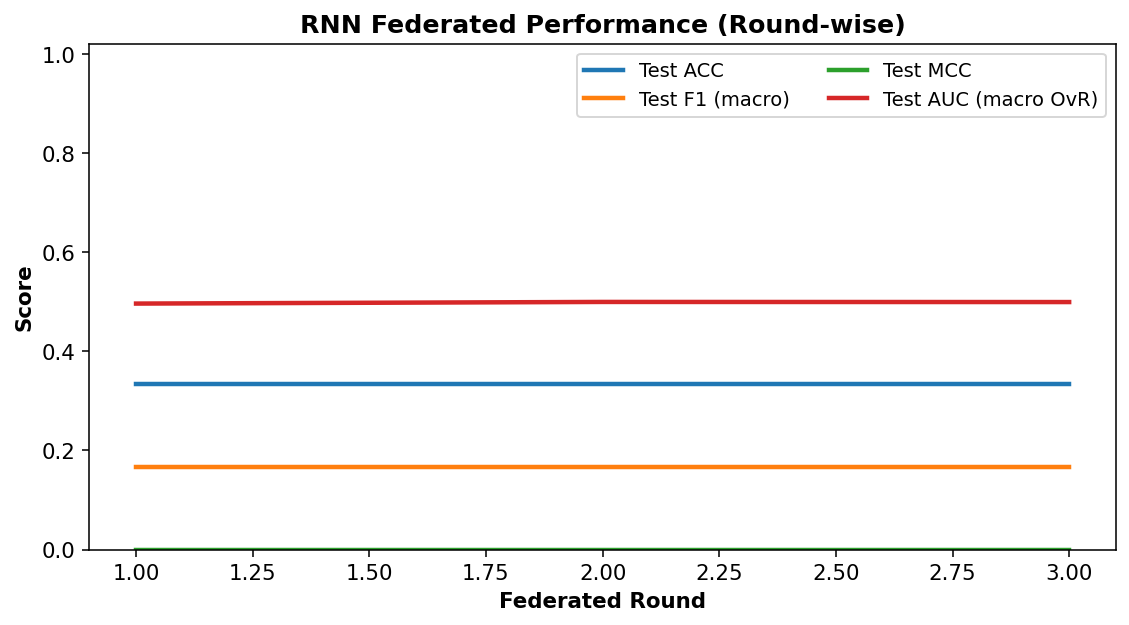

Saved figure: results_nomophobia_ulcer_pipeline/Nomophobia3Class_FL_DP_SecAgg_RNN_C5_R3_E3_20260102_165248_cm_norm.png


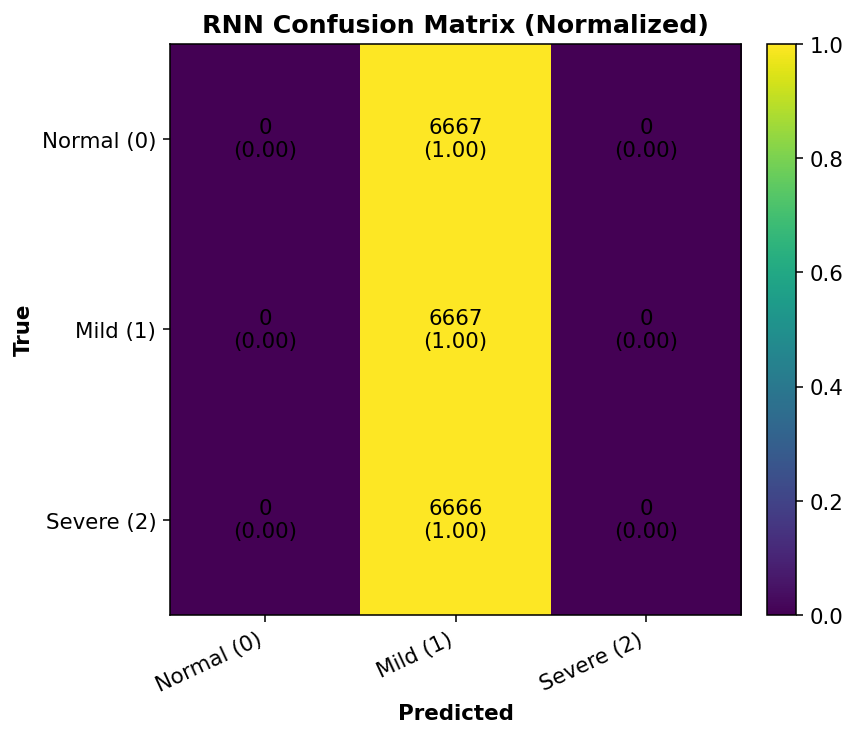

Saved figure: results_nomophobia_ulcer_pipeline/Nomophobia3Class_FL_DP_SecAgg_RNN_C5_R3_E3_20260102_165248_roc_ovr.png


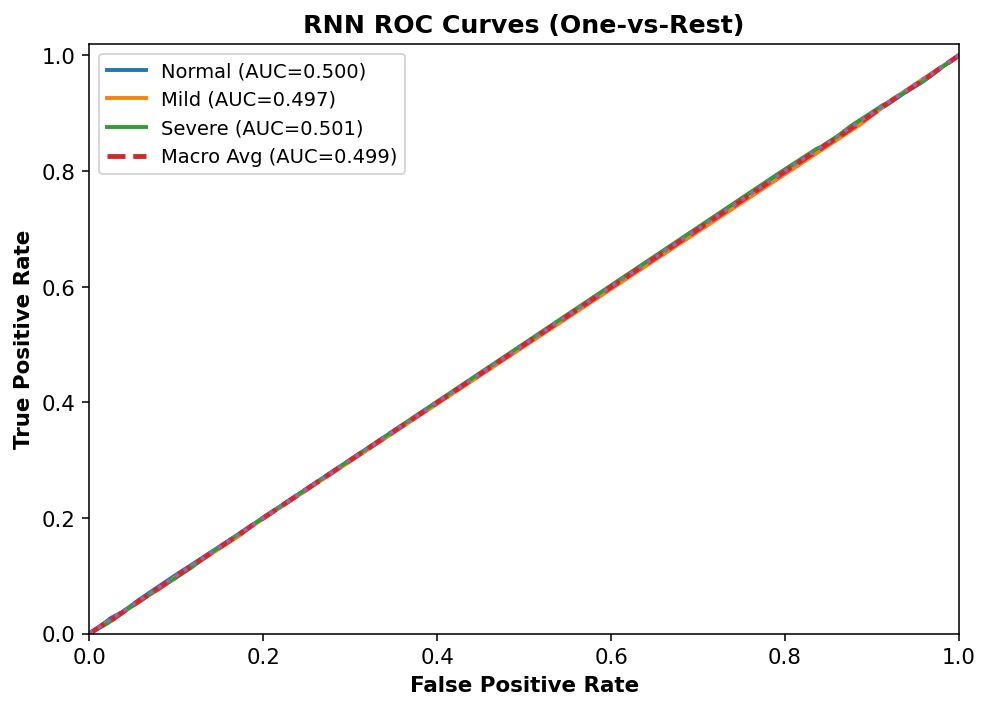

,Run,ModelType,NUM_CLIENTS,NUM_ROUNDS,LOCAL_EPOCHS,BATCH_SIZE,LR,WEIGHT_DECAY,DP_ENABLED,DP_CLIP_NORM,...,AUC_macro_ovr,PRE_Normal,PRE_Mild,PRE_Severe,RECALL_Normal,RECALL_Mild,RECALL_Severe,F1_Normal,F1_Mild,F1_Severe
0,Nomophobia3Class_FL_DP_SecAgg_RNN_C5_R3_E3_202...,rnn,5.0000,3.0000,3.0000,32.0000,0.0010,0.0001,0.0000,0.8000,...,0.4993,0.0000,0.3333,0.0000,0.0000,1.0000,0.0000,0.0000,0.5000,0.0000


Saved: results_nomophobia_ulcer_pipeline/Nomophobia3Class_FL_DP_SecAgg_RNN_C5_R3_E3_20260102_165248_metrics.csv
Saved: results_nomophobia_ulcer_pipeline/Nomophobia3Class_FL_DP_SecAgg_RNN_C5_R3_E3_20260102_165248_metrics.xlsx
Updated: results_nomophobia_ulcer_pipeline/MASTER_RESULTS.csv
Updated: results_nomophobia_ulcer_pipeline/MASTER_RESULTS.xlsx


In [ ]:
# ===============================
# Cell 12 — Pro plots + Metrics table + Save (CSV + Excel + MASTER)
# ===============================
import matplotlib.pyplot as plt

# =========================
# Cell 12 — PLOTS (add this at the TOP of the cell)
# =========================
def _model_display_name(m):
    m = str(m).strip().lower()
    mapping = {
        "cnn": "CNN",
        "rnn": "RNN",
        "lstm": "LSTM",
        "bilstm": "Bi-LSTM",
        "bi-lstm": "Bi-LSTM",
        "gnn": "GNN",
        "ann": "ANN",
        "mlp": "MLP",
    }
    return mapping.get(m, str(m).upper() if m else "MODEL")

# Get model name from CFG (preferred) or fallback variables
if "CFG" in globals() and isinstance(CFG, dict):
    MODEL_NAME = _model_display_name(CFG.get("MODEL_TYPE", CFG.get("MODEL_NAME", "")))
elif "MODEL_TYPE" in globals():
    MODEL_NAME = _model_display_name(MODEL_TYPE)
else:
    MODEL_NAME = "MODEL"


def _savefig(path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=int(CFG["PLOT_DPI"]), bbox_inches="tight")
    print("Saved figure:", path)

plt.rcParams.update({
    "figure.dpi": int(CFG["PLOT_DPI"]),
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.labelweight": "bold",
    "legend.frameon": True,
    "legend.fontsize": 10,
})

# -------- 1) Round-wise curves --------
plt.figure(figsize=(8.2, 4.6))
plt.plot(history_df["round"], history_df["test_acc"], linewidth=2.3, label="Test ACC")
plt.plot(history_df["round"], history_df["test_f1"],  linewidth=2.3, label="Test F1 (macro)")
plt.plot(history_df["round"], history_df["test_mcc"], linewidth=2.3, label="Test MCC")
# AUC might contain None
auc_vals = pd.to_numeric(history_df["test_auc"], errors="coerce")
plt.plot(history_df["round"], auc_vals, linewidth=2.3, label="Test AUC (macro OvR)")
plt.xlabel("Federated Round"); plt.ylabel("Score"); plt.ylim(0, 1.02)
plt.title(f"{MODEL_NAME} Federated Performance (Round-wise)")
plt.legend(ncol=2)
_savefig(os.path.join(RESULTS_DIR, f"{RUN_NAME}_curve_metrics.png"))
plt.show()

# -------- 2) Confusion Matrix (3-class) --------
cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
cm_norm = cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(6.2, 5.4))
plt.imshow(cm_norm, interpolation="nearest")
plt.title(f"{MODEL_NAME} Confusion Matrix (Normalized)")
#plt.title("Confusion Matrix (Normalized)")
plt.colorbar(fraction=0.046, pad=0.04)
ticks = np.arange(num_classes)
plt.xticks(ticks, [f"{n} ({i})" for i,n in enumerate(CFG["CLASS_NAMES"])], rotation=25, ha="right")
plt.yticks(ticks, [f"{n} ({i})" for i,n in enumerate(CFG["CLASS_NAMES"])])
plt.xlabel("Predicted"); plt.ylabel("True")

# annotate
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]:.2f})", ha="center", va="center")
_savefig(os.path.join(RESULTS_DIR, f"{RUN_NAME}_cm_norm.png"))
plt.show()

# -------- 3) ROC curves (OvR) --------
# One-vs-rest ROC per class + macro average
y_true_oh = np.eye(num_classes)[y_true]

plt.figure(figsize=(7.2, 5.2))
all_fpr = np.unique(np.concatenate([roc_curve(y_true_oh[:,c], y_prob[:,c])[0] for c in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for c in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_oh[:, c], y_prob[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{CFG['CLASS_NAMES'][c]} (AUC={roc_auc:.3f})")
    mean_tpr += np.interp(all_fpr, fpr, tpr)

mean_tpr /= num_classes
macro_auc = auc(all_fpr, mean_tpr)
plt.plot(all_fpr, mean_tpr, linewidth=2.5, linestyle="--", label=f"Macro Avg (AUC={macro_auc:.3f})")

plt.plot([0,1],[0,1], linestyle=":", linewidth=2)
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"{MODEL_NAME} ROC Curves (One-vs-Rest)")
plt.legend()
_savefig(os.path.join(RESULTS_DIR, f"{RUN_NAME}_roc_ovr.png"))
plt.show()

# -------- Metrics (macro) + per-class --------
acc = accuracy_score(y_true, y_pred)
pre_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro  = f1_score(y_true, y_pred, average="macro", zero_division=0)
mcc = matthews_corrcoef(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)

try:
    auc_macro = roc_auc_score(y_true_oh, y_prob, multi_class="ovr", average="macro")
except Exception:
    auc_macro = None

# per-class (paper friendly)
pre_cls = precision_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
rec_cls = recall_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)
f1_cls  = f1_score(y_true, y_pred, average=None, labels=[0,1,2], zero_division=0)

row = {
    "Run": RUN_NAME,
    "ModelType": CFG["MODEL_TYPE"],
    "NUM_CLIENTS": CFG["NUM_CLIENTS"],
    "NUM_ROUNDS": CFG["NUM_ROUNDS"],
    "LOCAL_EPOCHS": CFG["LOCAL_EPOCHS"],
    "BATCH_SIZE": CFG["BATCH_SIZE"],
    "LR": CFG["LR"],
    "WEIGHT_DECAY": CFG["WEIGHT_DECAY"],
    "DP_ENABLED": CFG["DP_ENABLED"],
    "DP_CLIP_NORM": CFG["DP_CLIP_NORM"],
    "DP_NOISE_MULT": CFG["DP_NOISE_MULT"],
    "MASK_ENABLED": CFG["MASK_ENABLED"],
    "MASK_SCALE": CFG["MASK_SCALE"],
    "ENC_ENABLED": CFG["ENC_ENABLED"],
    "ACC_macro": acc,
    "PRE_macro": pre_macro,
    "RECALL_macro": rec_macro,
    "F1_macro": f1_macro,
    "MCC": mcc,
    "BalancedACC": bacc,
    "AUC_macro_ovr": auc_macro,
    "PRE_Normal": pre_cls[0],
    "PRE_Mild": pre_cls[1],
    "PRE_Severe": pre_cls[2],
    "RECALL_Normal": rec_cls[0],
    "RECALL_Mild": rec_cls[1],
    "RECALL_Severe": rec_cls[2],
    "F1_Normal": f1_cls[0],
    "F1_Mild": f1_cls[1],
    "F1_Severe": f1_cls[2],
}

df_metrics = pd.DataFrame([row])

# Display rounded
df_show = df_metrics.copy()
for c in df_show.columns:
    if df_show[c].dtype != "O":
        df_show[c] = df_show[c].map(lambda x: "-" if x is None or (isinstance(x, float) and np.isnan(x)) else f"{x:.4f}")
display(df_show)

# Save per-run (CSV + Excel)
single_csv = os.path.join(RESULTS_DIR, f"{RUN_NAME}_metrics.csv")
single_xlsx = os.path.join(RESULTS_DIR, f"{RUN_NAME}_metrics.xlsx")
df_metrics.to_csv(single_csv, index=False)
df_metrics.to_excel(single_xlsx, index=False)
print("Saved:", single_csv)
print("Saved:", single_xlsx)

# Append MASTER (CSV + Excel)
master_csv = os.path.join(RESULTS_DIR, "MASTER_RESULTS.csv")
if os.path.exists(master_csv):
    df_master = pd.read_csv(master_csv)
    df_master = pd.concat([df_master, df_metrics], ignore_index=True)
else:
    df_master = df_metrics.copy()
df_master.to_csv(master_csv, index=False)
print("Updated:", master_csv)

master_xlsx = os.path.join(RESULTS_DIR, "MASTER_RESULTS.xlsx")
try:
    if os.path.exists(master_xlsx):
        df_old = pd.read_excel(master_xlsx)
        df_new = pd.concat([df_old, df_metrics], ignore_index=True)
    else:
        df_new = df_metrics.copy()
    df_new.to_excel(master_xlsx, index=False)
    print("Updated:", master_xlsx)
except Exception as e:
    print("Excel MASTER not updated (openpyxl missing or file locked):", e)
